## **PRÉDICTION DES VENTES HEBDOMADAIRES WALMART**
Objectif : Prédire `Weekly_Sales`, comprendre les facteurs clés, éviter l'overfitting

## **Partie 1. Exploration et Analyse des données (EDA)**

Plan de notebook: 
- statistiques descriptives
- détection des valeurs manquantes
- visualisations des distributions
- corrélations
- analyse business


In [27]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
 
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

walmart_store_sales_data = '../data/Walmart_Store_sales.csv'
output_images_path = '../output/images'

In [16]:
df = pd.read_csv(walmart_store_sales_data)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


### **STATISTIQUES DESCRIPTIVES**

In [17]:
df.describe(include='all').round(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.00,132,136.00,138.00,132.00,136.00,138.00,135.00
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,07-01-2011,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.87,NaN,1249535.83,0.08,61.40,3.32,179.90,7.60
std,6.23,NaN,647463.04,0.27,18.38,0.48,40.27,1.58
min,1.00,NaN,268929.03,0.00,18.79,2.51,126.11,5.14
25%,4.00,NaN,605075.72,0.00,45.59,2.85,131.97,6.60
50%,9.00,NaN,1261423.86,0.00,62.98,3.45,197.91,7.47
75%,15.75,NaN,1806386.20,0.00,76.34,3.71,214.93,8.15


**ANALYSE DES VALEURS MANQUANTES**

In [18]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Variable': missing.index,
    'Manquantes': missing.values,
    '% du total': missing_pct.values
}).sort_values('Manquantes', ascending=False)

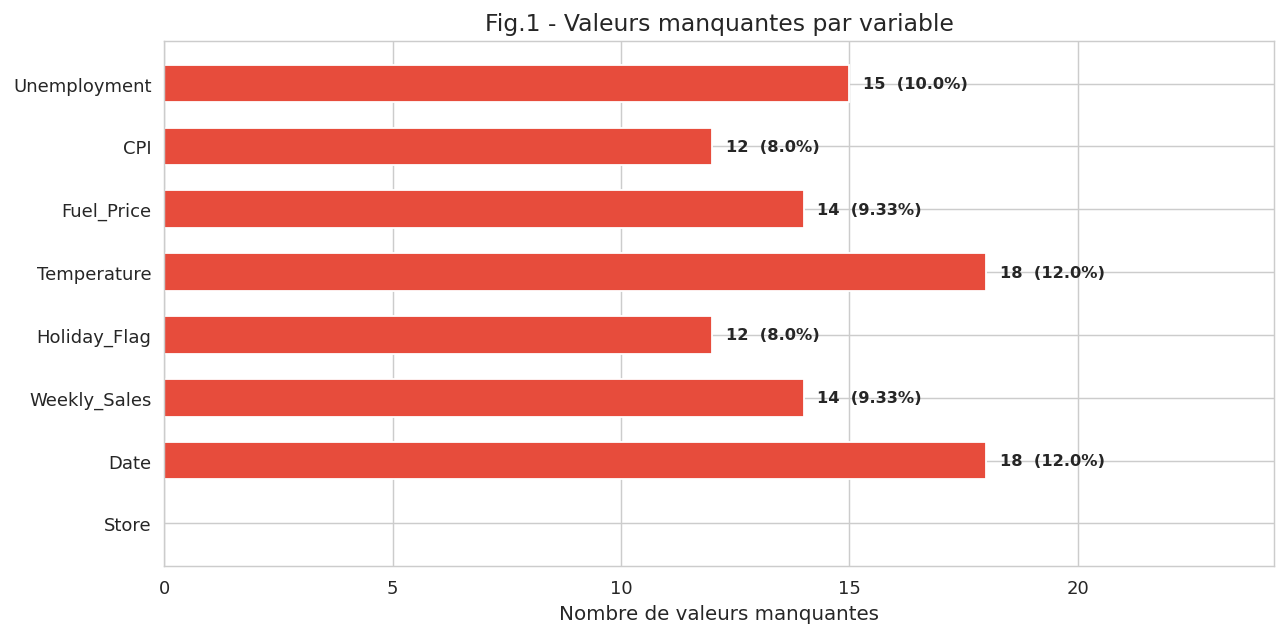

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 0 else '#27ae60' for v in missing.values]
bars = ax.barh(missing.index, missing.values, color=colors, edgecolor='white', height=0.6)

ax.set_xlabel("Nombre de valeurs manquantes")
ax.set_title("Fig.1 - Valeurs manquantes par variable")

for i, (v, pct) in enumerate(zip(missing.values, missing_pct.values)):
    if v > 0:
        ax.text(v + 0.3, i, f"{v}  ({pct}%)", va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, max(missing.values) * 1.35)
plt.tight_layout()
plt.savefig(f"{output_images_path}/01_valeurs_manquantes.png", bbox_inches='tight')
plt.show()

### **DISTRIBUTION DE LA VARIABLE CIBLE (Weekly_Sales)**

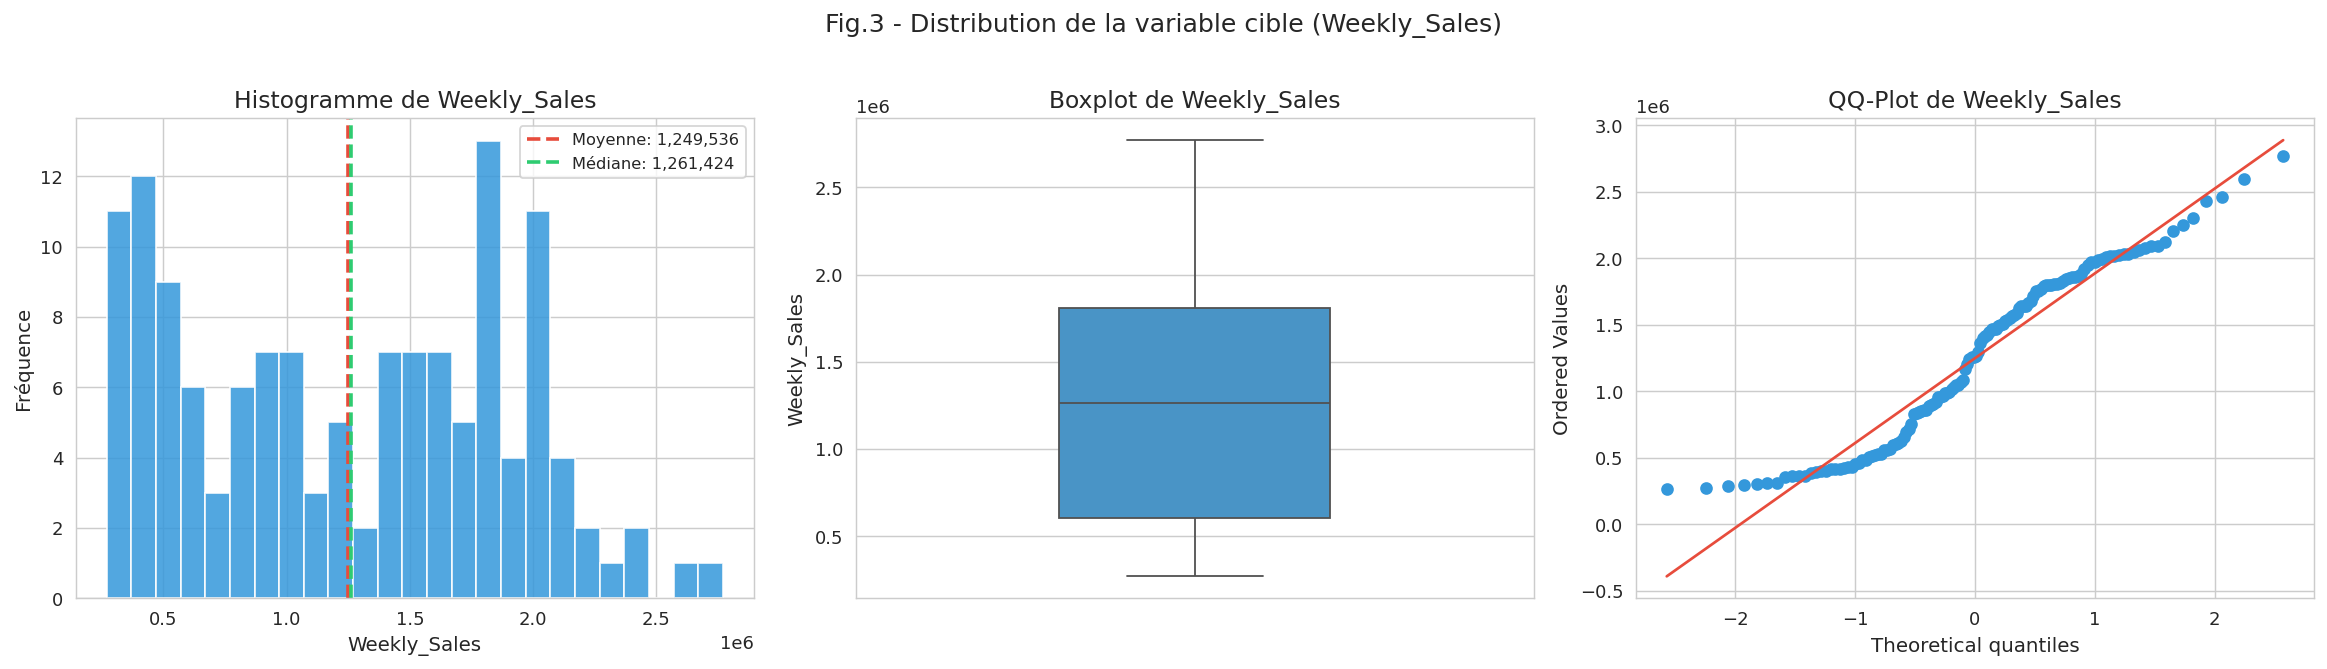

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ws = df['Weekly_Sales'].dropna()
 
# Histogramme
axes[0].hist(ws, bins=25, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(ws.mean(), color='#e74c3c', ls='--', lw=2, label=f'Moyenne: {ws.mean():,.0f}')
axes[0].axvline(ws.median(), color='#2ecc71', ls='--', lw=2, label=f'Médiane: {ws.median():,.0f}')
axes[0].set_title("Histogramme de Weekly_Sales")
axes[0].set_xlabel("Weekly_Sales")
axes[0].set_ylabel("Fréquence")
axes[0].legend(fontsize=9)
 
# Boxplot
sns.boxplot(y=ws, ax=axes[1], color='#3498db', width=0.4)
axes[1].set_title("Boxplot de Weekly_Sales")
axes[1].set_ylabel("Weekly_Sales")

# QQ-plot (vérification normalité)
stats.probplot(ws, plot=axes[2])
axes[2].set_title("QQ-Plot de Weekly_Sales")
axes[2].get_lines()[0].set_color('#3498db')
axes[2].get_lines()[1].set_color('#e74c3c')
 
plt.suptitle("Fig.3 - Distribution de la variable cible (Weekly_Sales)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_images_path}/02_distribution_target.png", bbox_inches='tight')
plt.show()
plt.close()


### **DISTRIBUTIONS DES VARIABLES NUMÉRIQUES**

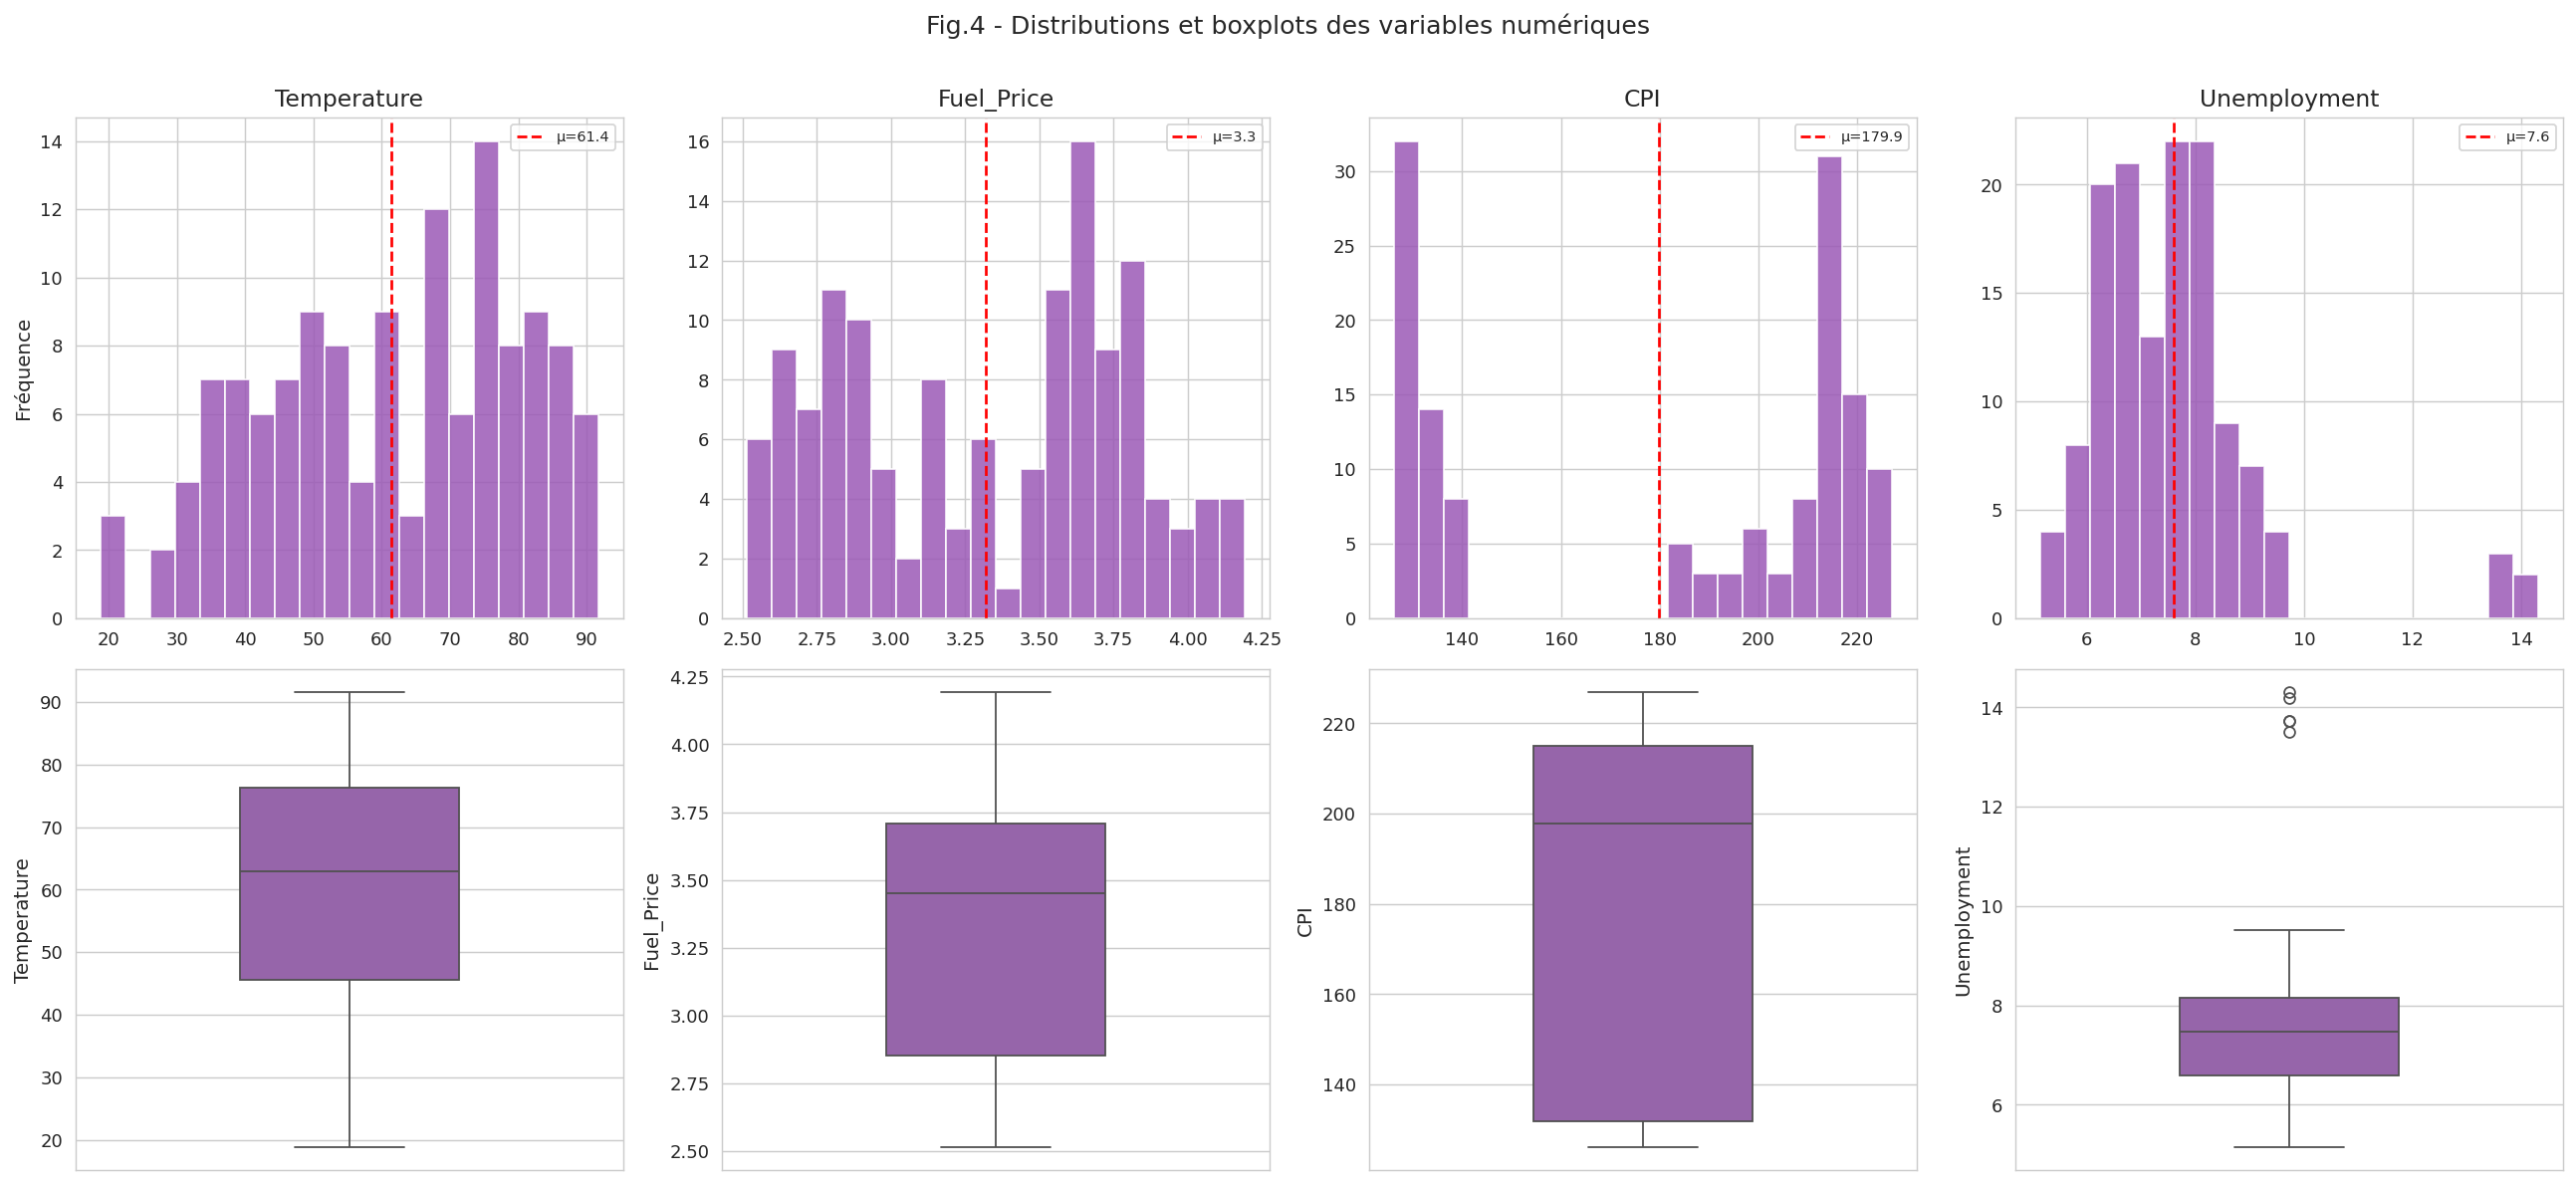

In [29]:
num_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
 
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
 
for i, col in enumerate(num_cols):
    data = df[col].dropna()
 
    # Ligne 1 : Histogrammes
    ax = axes[0][i]
    ax.hist(data, bins=20, color='#9b59b6', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', ls='--', lw=1.5, label=f'μ={data.mean():.1f}')
    ax.set_title(col)
    ax.legend(fontsize=8)
    if i == 0:
        ax.set_ylabel("Fréquence")
 
    # Ligne 2 : Boxplots
    ax2 = axes[1][i]
    sns.boxplot(y=data, ax=ax2, color='#9b59b6', width=0.4)
    ax2.set_ylabel(col)
 
plt.suptitle("Fig.4 - Distributions et boxplots des variables numériques", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{output_images_path}/03_distributions_numeriques.png", bbox_inches='tight')
plt.show()
plt.close()

### **VENTES PAR MAGASIN**

In [32]:
store_stats = df.groupby('Store')['Weekly_Sales'].agg(['mean', 'median', 'std', 'count']).round(2)
store_stats.columns = ['Moyenne', 'Médiane', 'Écart-type', 'Nb_obs']
store_stats = store_stats.sort_values('Moyenne', ascending=False)
 
print("Ventes par magasin (trié par moyenne décroissante)\n")
print(store_stats.to_string())


Ventes par magasin (trié par moyenne décroissante)

          Moyenne     Médiane  Écart-type  Nb_obs
Store                                            
4.0    2173758.98  2051386.62   326041.87       6
14.0   2092878.41  2077256.24   224850.53       9
13.0   1997235.41  1997397.63   197428.54       9
20.0   1962384.41  1973135.87   174288.58       5
2.0    1943033.62  1857482.34   228038.68       8
10.0   1822105.81  1805999.79   103914.57       5
1.0    1562508.32  1539483.70    89106.16       9
6.0    1551123.58  1552213.16    86249.34       6
11.0   1523746.83  1569607.94   259483.81       3
19.0   1400615.22  1416015.44   101501.01       8
18.0   1140436.54  1080565.13   183290.95      10
12.0   1028025.01   964332.51   155326.05       5
17.0    891605.95   855459.96    99359.27       7
8.0     888754.13   874576.47    56255.82       6
15.0    633580.40   634157.10    55409.97       4
7.0     559129.95   562302.96    95145.96       8
16.0    515317.77   505810.28    75750.78       

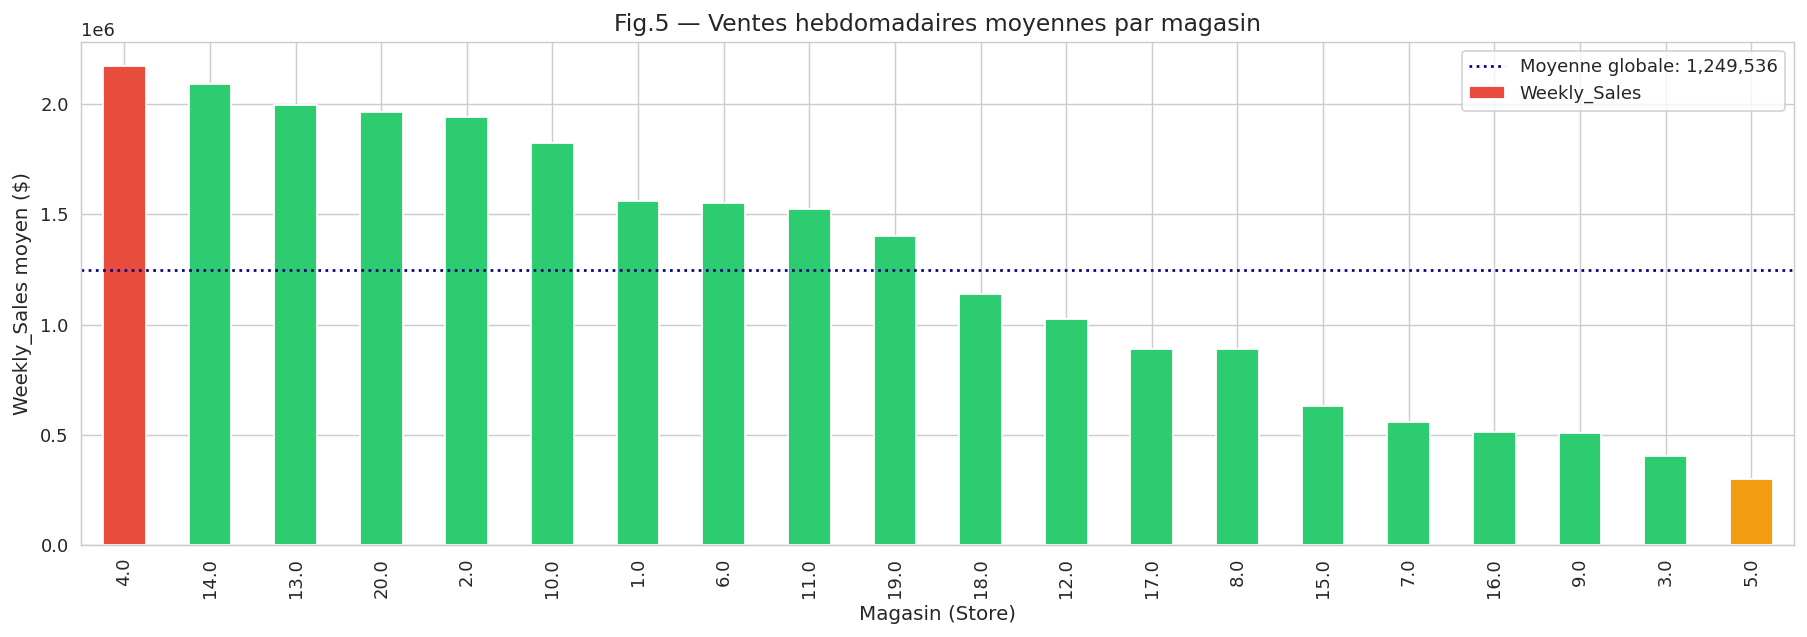

In [33]:
top_store = store_stats.index[0]
bot_store = store_stats.index[-1]
ratio = store_stats.iloc[0]['Moyenne'] / store_stats.iloc[-1]['Moyenne']

fig, ax = plt.subplots(figsize=(14, 5))
store_mean = df.groupby('Store')['Weekly_Sales'].mean().dropna().sort_values(ascending=False)

colors = ['#e74c3c' if s == top_store else '#f39c12' if s == bot_store else '#2ecc71' for s in store_mean.index]
store_mean.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title("Fig.5 — Ventes hebdomadaires moyennes par magasin")
ax.set_xlabel("Magasin (Store)")
ax.set_ylabel("Weekly_Sales moyen ($)")
ax.axhline(ws.mean(), color='navy', ls=':', lw=1.5, label=f'Moyenne globale: {ws.mean():,.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(f"{output_images_path}/04_ventes_par_magasin.png", bbox_inches='tight')
plt.show()
plt.close()

### **IMPACT DES JOURS FÉRIÉS**


                       mean      median        std  count
Non-Holiday (0)  1239575.69  1249738.64  662741.11    116
Holiday (1)      1333024.34  1641957.44  568667.18      9


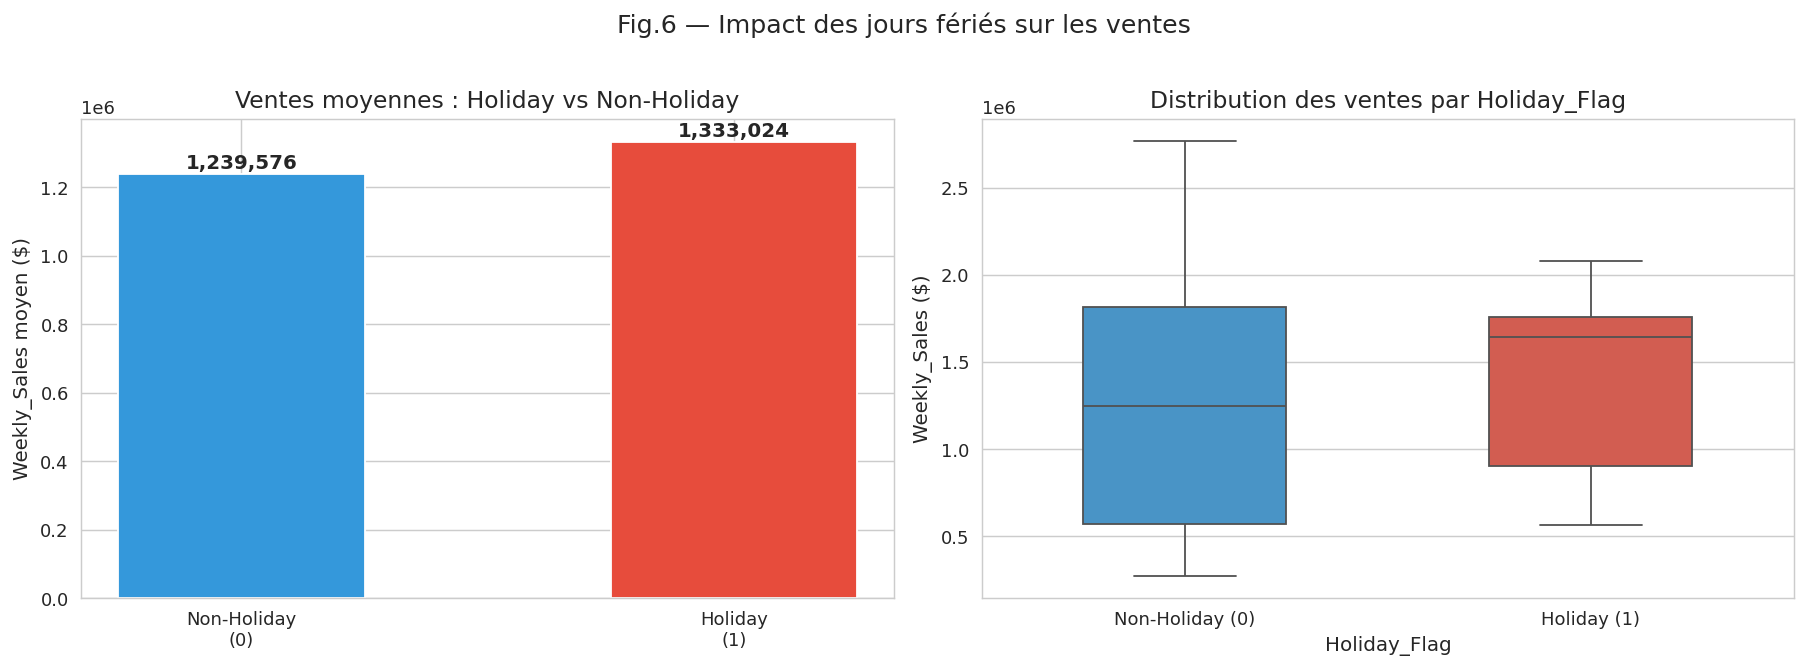

In [36]:
holiday_stats = df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean', 'median', 'std', 'count']).round(2)
holiday_stats.index = ['Non-Holiday (0)', 'Holiday (1)']
print("\n" + holiday_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Bar chart
h_mean = df.groupby('Holiday_Flag')['Weekly_Sales'].mean().dropna()
bars = axes[0].bar(['Non-Holiday\n(0)', 'Holiday\n(1)'], h_mean.values,
                    color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title("Ventes moyennes : Holiday vs Non-Holiday")
axes[0].set_ylabel("Weekly_Sales moyen ($)")
for bar, val in zip(bars, h_mean.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
                 f'{val:,.0f}', ha='center', fontweight='bold', fontsize=11)
 
# Boxplot comparatif
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df.dropna(subset=['Holiday_Flag', 'Weekly_Sales']),
            ax=axes[1], palette=['#3498db', '#e74c3c'], width=0.5)
axes[1].set_title("Distribution des ventes par Holiday_Flag")
axes[1].set_xticklabels(['Non-Holiday (0)', 'Holiday (1)'])
axes[1].set_ylabel("Weekly_Sales ($)")
 
plt.suptitle("Fig.6 — Impact des jours fériés sur les ventes", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{output_images_path}/05_holiday_impact.png", bbox_inches='tight')
plt.show()
plt.close()


### **MATRICE DE CORRÉLATION**


              Weekly_Sales  Store  Holiday_Flag  Temperature  Fuel_Price    CPI  Unemployment
Weekly_Sales         1.000  0.116         0.037       -0.166      -0.019 -0.287         0.055
Store                0.116  1.000        -0.026       -0.260       0.183 -0.588         0.224
Holiday_Flag         0.037 -0.026         1.000       -0.188      -0.117  0.172         0.097
Temperature         -0.166 -0.260        -0.188        1.000       0.049  0.138        -0.030
Fuel_Price          -0.019  0.183        -0.117        0.049       1.000 -0.160         0.086
CPI                 -0.287 -0.588         0.172        0.138      -0.160  1.000        -0.348
Unemployment         0.055  0.224         0.097       -0.030       0.086 -0.348         1.000

Corrélations avec Weekly_Sales
   CPI             : r = -0.287  (faible, négative)
   Temperature     : r = -0.166  (faible, négative)
   Store           : r = +0.116  (faible, positive)
   Unemployment    : r = +0.055  (faible, positive)
   Holi

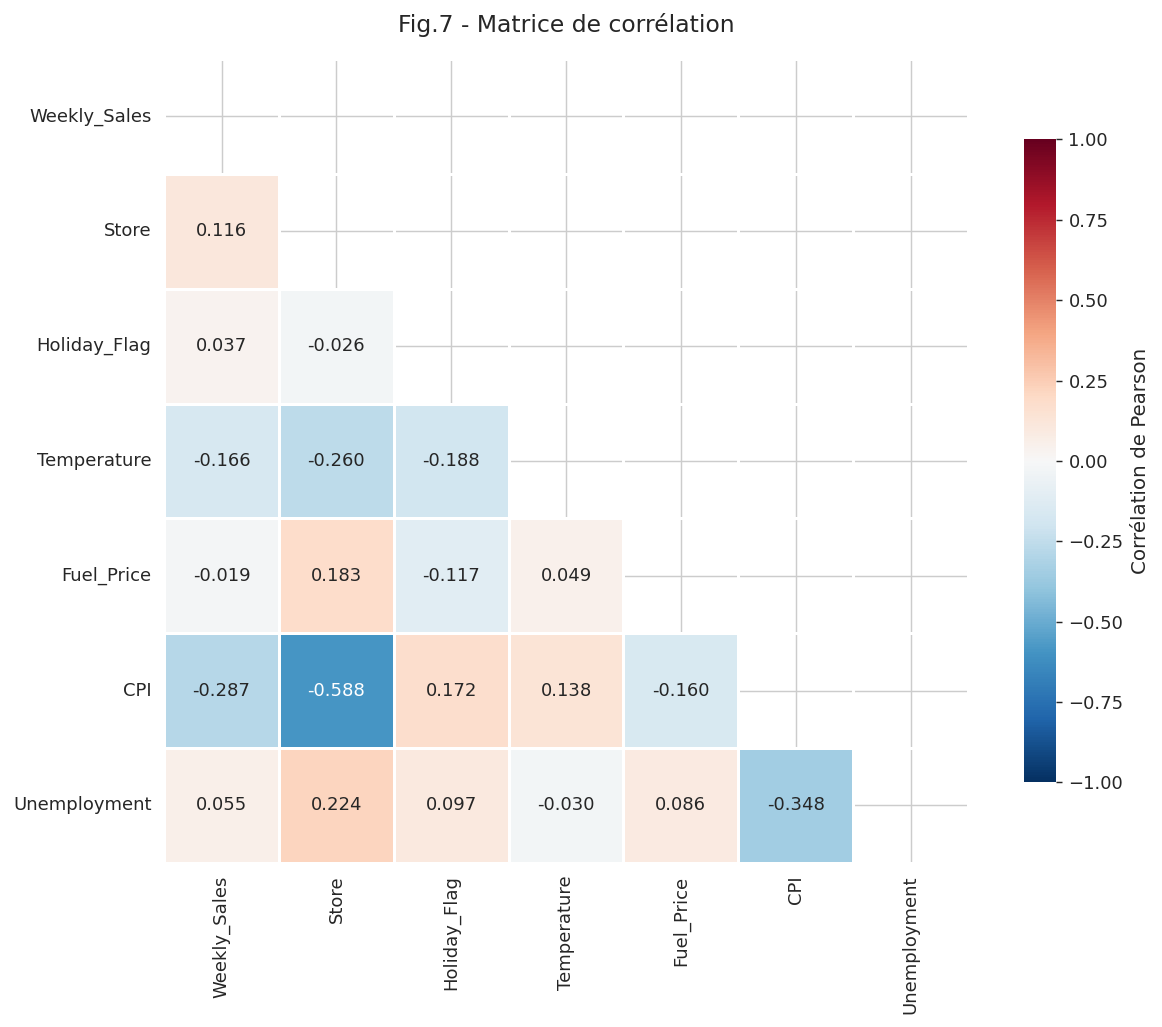

In [38]:
corr_cols = ['Weekly_Sales', 'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df[corr_cols].corr().round(3)
 
print("\n" + corr_matrix.to_string())
 
# Corrélations avec la target
print("\nCorrélations avec Weekly_Sales")
target_corr = corr_matrix['Weekly_Sales'].drop('Weekly_Sales').sort_values(key=abs, ascending=False)

for feat, r in target_corr.items():
    strength = "forte" if abs(r) > 0.5 else "moyenne" if abs(r) > 0.3 else "faible"
    direction = "positive" if r > 0 else "négative"
    print(f"   {feat:<15} : r = {r:+.3f}  ({strength}, {direction})")
 
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.8,
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'},
            vmin=-1, vmax=1)

ax.set_title("Fig.7 - Matrice de corrélation", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f"{output_images_path}/06_correlation_matrix.png", bbox_inches='tight')
plt.show()
plt.close()

### **SCATTER PLOTS — VARIABLES VS TARGET**

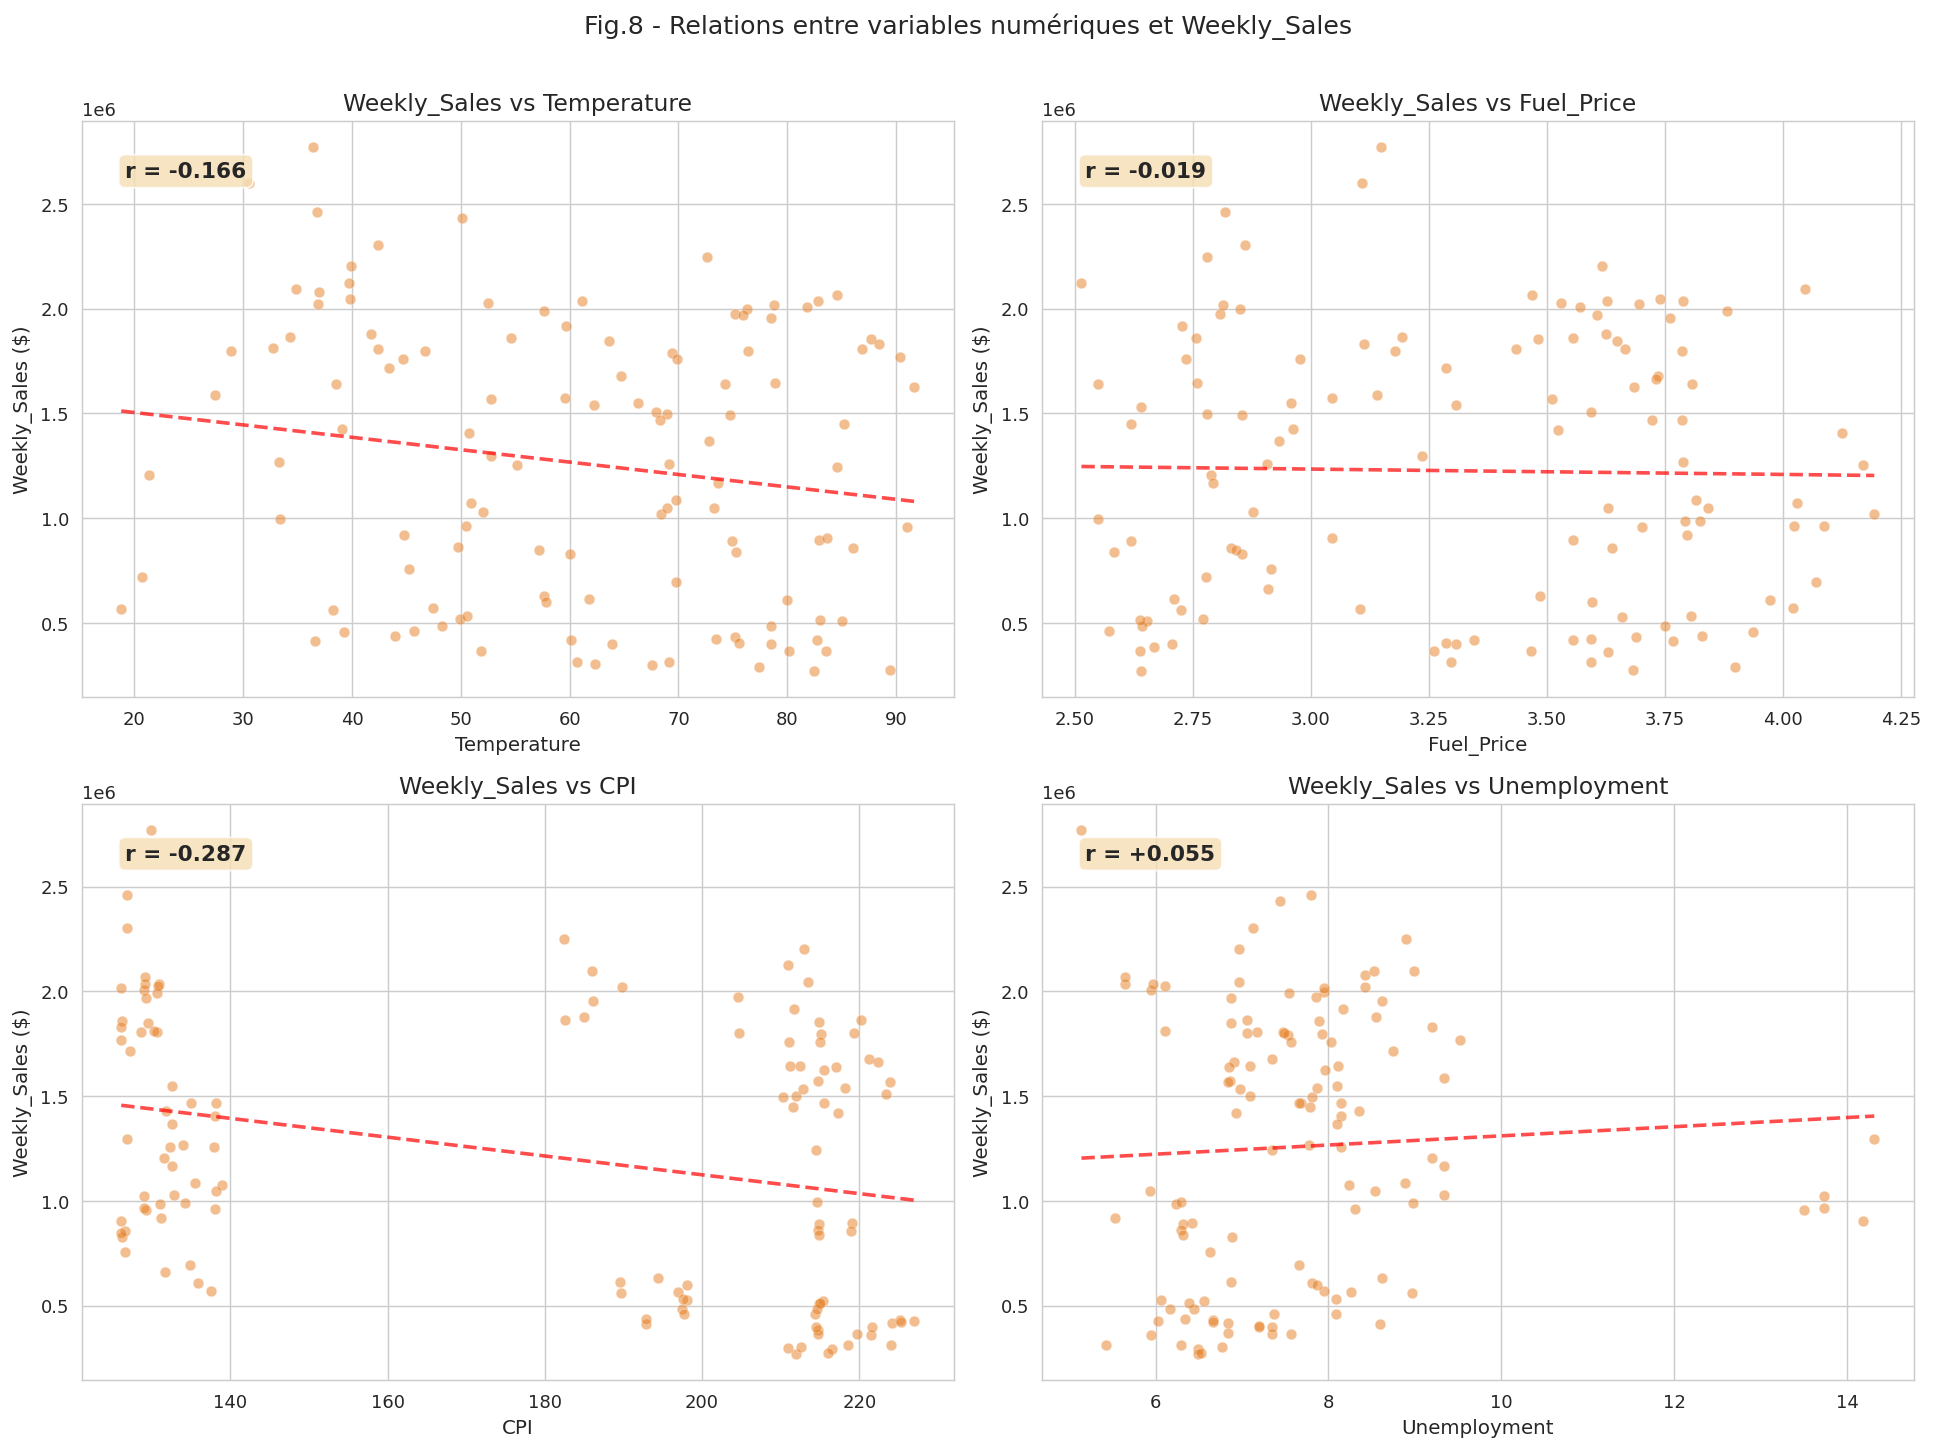

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
 
for i, col in enumerate(num_cols):
    ax = axes[i // 2][i % 2]
    valid = df[[col, 'Weekly_Sales']].dropna()
    ax.scatter(valid[col], valid['Weekly_Sales'], alpha=0.5, s=35, color='#e67e22', edgecolor='white', lw=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel("Weekly_Sales ($)")
    ax.set_title(f"Weekly_Sales vs {col}")
 
    # Ligne de tendance
    z = np.polyfit(valid[col], valid['Weekly_Sales'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', lw=2, alpha=0.7)
 
    # Corrélation
    r = valid[col].corr(valid['Weekly_Sales'])
    ax.text(0.05, 0.93, f"r = {r:+.3f}", transform=ax.transAxes, fontsize=12,
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))
 
plt.suptitle("Fig.8 - Relations entre variables numériques et Weekly_Sales", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{output_images_path}/07_scatter_vs_target.png", bbox_inches='tight')
plt.show()
plt.close()

### **PAIRPLOT (vue globale)**

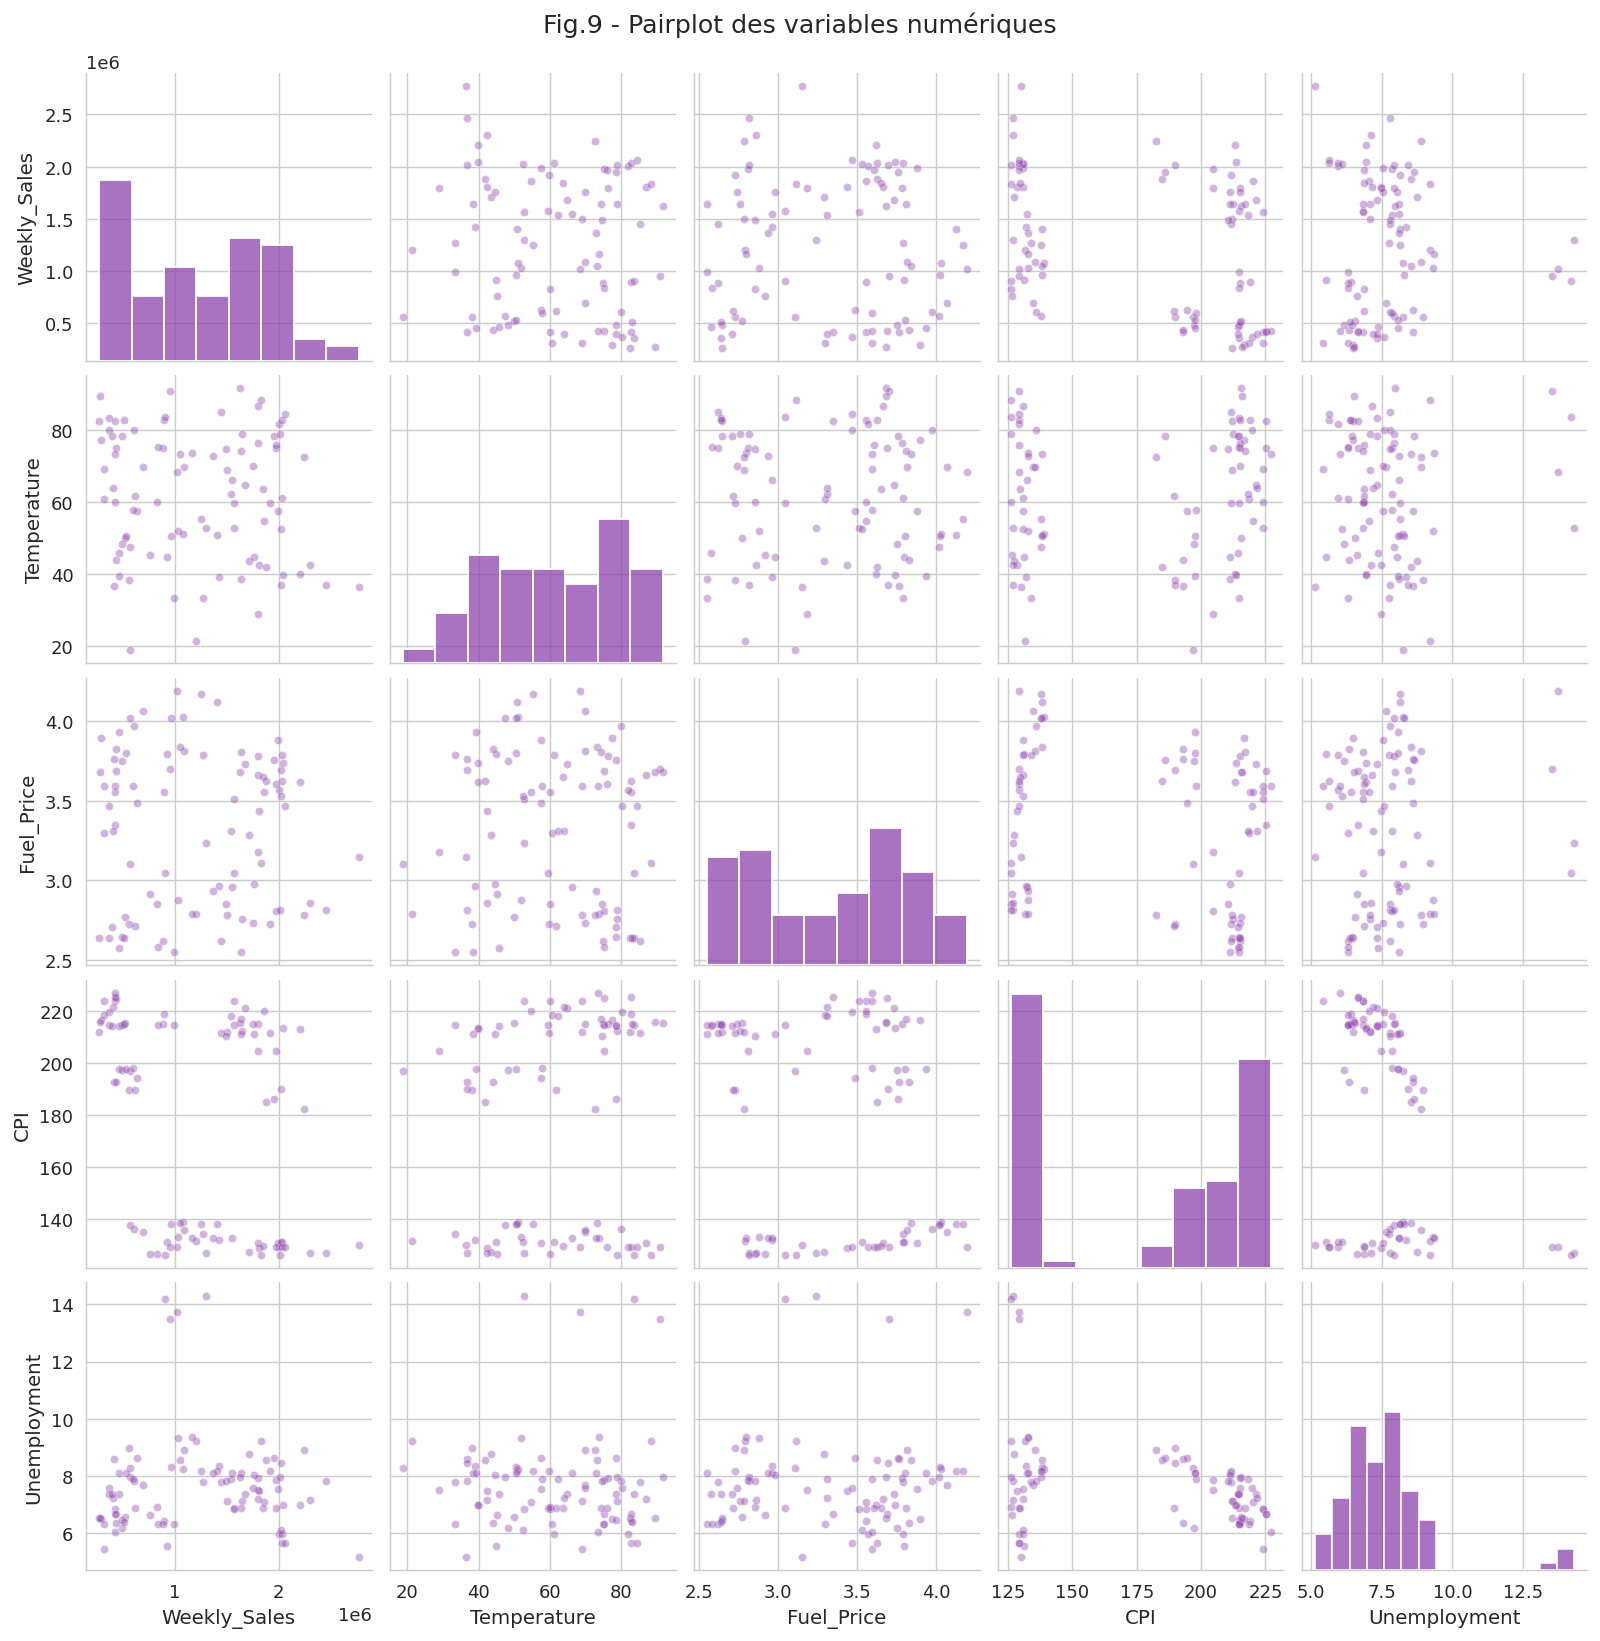

In [40]:
pairplot_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
g = sns.pairplot(df[pairplot_cols].dropna(), diag_kind='hist',
                 plot_kws={'alpha': 0.4, 's': 20, 'color': '#8e44ad'},
                 diag_kws={'color': '#8e44ad', 'edgecolor': 'white'})
                 
g.figure.suptitle("Fig.9 - Pairplot des variables numériques", y=1.01, fontsize=14)
plt.savefig(f"{output_images_path}/08_pairplot.png", bbox_inches='tight')
plt.show()
plt.close()

### **SYNTHÈSE EDA**

In [43]:
print(f"""
RÉSUMÉ DU DATASET :
- {df.shape[0]} observations, {df.shape[1]} variables
- {int(df['Store'].dropna().nunique())} magasins (Store 1 -> {int(df['Store'].dropna().max())})
- Target : Weekly_Sales (continue, range {ws.min():,.0f} -> {ws.max():,.0f})
 
VALEURS MANQUANTES :
- Toutes les colonnes ont des NaN (8% à 12%)
- {df['Weekly_Sales'].isnull().sum()} valeurs manquantes sur Weekly_Sales => à supprimer
- {df['Date'].isnull().sum()} dates manquantes => à supprimer
- Les autres variables => à imputer
 
OBSERVATIONS CLÉS :
- Weekly_Sales : distribution légèrement asymétrique (skew = {ws.skew():.2f})
- Grande variabilité entre magasins (ratio max/min ~ {ratio:.1f}x)
- Les corrélations avec la target sont globalement faibles
- Store est la variable la plus discriminante
- Les holidays semblent avoir un impact positif sur les ventes
 
POINTS D'ATTENTION POUR LE PREPROCESSING :
- Outliers à vérifier sur Temperature, Fuel_Price, CPI, Unemployment
- Feature engineering sur Date (Year, Month, Day, DayOfWeek)
- Encoding nécessaire pour Store (catégoriel)
""")


RÉSUMÉ DU DATASET :
- 150 observations, 8 variables
- 20 magasins (Store 1 -> 20)
- Target : Weekly_Sales (continue, range 268,929 -> 2,771,397)

VALEURS MANQUANTES :
- Toutes les colonnes ont des NaN (8% à 12%)
- 14 valeurs manquantes sur Weekly_Sales => à supprimer
- 18 dates manquantes => à supprimer
- Les autres variables => à imputer

OBSERVATIONS CLÉS :
- Weekly_Sales : distribution légèrement asymétrique (skew = 0.08)
- Grande variabilité entre magasins (ratio max/min ~ 7.2x)
- Les corrélations avec la target sont globalement faibles
- Store est la variable la plus discriminante
- Les holidays semblent avoir un impact positif sur les ventes

POINTS D'ATTENTION POUR LE PREPROCESSING :
- Outliers à vérifier sur Temperature, Fuel_Price, CPI, Unemployment
- Feature engineering sur Date (Year, Month, Day, DayOfWeek)
- Encoding nécessaire pour Store (catégoriel)

